In [2]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
india = pd.read_csv(
    "IN_youtube_trending_data.csv",
    engine = "python",
    on_bad_lines="warn"
)


In [4]:
india.head()
print(india.columns.tolist())
print(india.info())

['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle', 'categoryId', 'trending_date', 'tags', 'view_count', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'description']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251277 entries, 0 to 251276
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   video_id           251277 non-null  object
 1   title              251277 non-null  object
 2   publishedAt        251277 non-null  object
 3   channelId          251277 non-null  object
 4   channelTitle       251276 non-null  object
 5   categoryId         251277 non-null  int64 
 6   trending_date      251277 non-null  object
 7   tags               251277 non-null  object
 8   view_count         251277 non-null  int64 
 9   likes              251277 non-null  int64 
 10  dislikes           251277 non-null  int64 
 11  comment_count      251277 non

In [5]:

usa = pd.read_csv(
    "US_youtube_trending_data.csv",
    engine = "python",
    on_bad_lines="warn"
)

uk = pd.read_csv(
    "GB_youtube_trending_data.csv",
    engine = "python",
    on_bad_lines="warn"
)

korea = pd.read_csv(
    "KR_youtube_trending_data.csv",
    encoding="latin-1",
    engine = "python",
    on_bad_lines="warn"
)

print("USA: ", usa.shape)
print("UK: ", uk.shape)
print("South Korea: ", korea.shape)

USA:  (268787, 16)
UK:  (268791, 16)
South Korea:  (265754, 16)


In [6]:
india["country"] = "India"
usa["country"] = "USA"
uk["country"] = "UK"
korea["country"] = "South Korea"


In [7]:

youtube = pd.concat(
    [india, usa, uk, korea],
    ignore_index=True
)

In [8]:
print("Combined dataset shape:", youtube.shape)

Combined dataset shape: (1054609, 17)


In [9]:
youtube.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,country
0,Iot0eF6EoNA,Sadak 2 | Official Trailer | Sanjay | Pooja | ...,2020-08-12T04:31:41Z,UCGqvJPRcv7aVFun-eTsatcA,FoxStarHindi,24,2020-08-12T00:00:00Z,sadak|sadak 2|mahesh bhatt|vishesh films|pooja...,9885899,224925,3979409,350210,https://i.ytimg.com/vi/Iot0eF6EoNA/default.jpg,False,False,Three Streams. Three Stories. One Journey. Sta...,India
1,x-KbnJ9fvJc,Kya Baat Aa : Karan Aujla (Official Video) Tan...,2020-08-11T09:00:11Z,UCm9SZAl03Rev9sFwloCdz1g,Rehaan Records,10,2020-08-12T00:00:00Z,[None],11308046,655450,33242,405146,https://i.ytimg.com/vi/x-KbnJ9fvJc/default.jpg,False,False,Singer/Lyrics: Karan Aujla Feat Tania Music/ D...,India
2,KX06ksuS6Xo,Diljit Dosanjh: CLASH (Official) Music Video |...,2020-08-11T07:30:02Z,UCZRdNleCgW-BGUJf-bbjzQg,Diljit Dosanjh,10,2020-08-12T00:00:00Z,clash diljit dosanjh|diljit dosanjh|diljit dos...,9140911,296533,6179,30058,https://i.ytimg.com/vi/KX06ksuS6Xo/default.jpg,False,False,CLASH official music video performed by DILJIT...,India
3,UsMRgnTcchY,Dil Ko Maine Di Kasam Video | Amaal M Ft.Ariji...,2020-08-10T05:30:49Z,UCq-Fj5jknLsUf-MWSy4_brA,T-Series,10,2020-08-12T00:00:00Z,hindi songs|2020 hindi songs|2020 new songs|t-...,23564512,743931,84162,136942,https://i.ytimg.com/vi/UsMRgnTcchY/default.jpg,False,False,Gulshan Kumar and T-Series presents Bhushan Ku...,India
4,WNSEXJJhKTU,"Baarish (Official Video) Payal Dev,Stebin Ben ...",2020-08-11T05:30:13Z,UCye6Oz0mg46S362LwARGVcA,VYRLOriginals,10,2020-08-12T00:00:00Z,VYRL Original|Mohsin Khan|Shivangi Joshi|Payal...,6783649,268817,8798,22984,https://i.ytimg.com/vi/WNSEXJJhKTU/default.jpg,False,False,VYRL Originals brings to you ‘Baarish’ - the b...,India


In [10]:
youtube.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054609 entries, 0 to 1054608
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype 
---  ------             --------------    ----- 
 0   video_id           1054609 non-null  object
 1   title              1054609 non-null  object
 2   publishedAt        1054609 non-null  object
 3   channelId          1054609 non-null  object
 4   channelTitle       1054608 non-null  object
 5   categoryId         1054609 non-null  int64 
 6   trending_date      1054609 non-null  object
 7   tags               1054609 non-null  object
 8   view_count         1054609 non-null  int64 
 9   likes              1054609 non-null  int64 
 10  dislikes           1054609 non-null  int64 
 11  comment_count      1054609 non-null  int64 
 12  thumbnail_link     1054609 non-null  object
 13  comments_disabled  1054609 non-null  bool  
 14  ratings_disabled   1054609 non-null  bool  
 15  description        1021371 non-null  object
 16  

In [11]:
youtube.isnull().sum()

,0
video_id,0
title,0
publishedAt,0
channelId,0
channelTitle,1
categoryId,0
trending_date,0
tags,0
view_count,0
likes,0


In [12]:
youtube.duplicated().sum()

np.int64(434)

In [13]:
youtube[["view_count", "likes", "dislikes", "comment_count"]].describe()

,view_count,likes,dislikes,comment_count
count,1.054609e+06,1.054609e+06,1.054609e+06,1.054609e+06
mean,2.380667e+06,1.129388e+05,1.207145e+03,8.409360e+03
std,7.767718e+06,4.047641e+05,3.574707e+04,7.350122e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.846000e+05,9.850000e+03,0.000000e+00,6.340000e+02
50%,8.121640e+05,2.698100e+04,0.000000e+00,1.680000e+03
75%,1.866903e+06,7.930900e+04,3.030000e+02,4.469000e+03
max,1.407644e+09,1.646425e+07,1.234147e+07,6.939302e+06


In [14]:
youtube.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054609 entries, 0 to 1054608
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype 
---  ------             --------------    ----- 
 0   video_id           1054609 non-null  object
 1   title              1054609 non-null  object
 2   publishedAt        1054609 non-null  object
 3   channelId          1054609 non-null  object
 4   channelTitle       1054608 non-null  object
 5   categoryId         1054609 non-null  int64 
 6   trending_date      1054609 non-null  object
 7   tags               1054609 non-null  object
 8   view_count         1054609 non-null  int64 
 9   likes              1054609 non-null  int64 
 10  dislikes           1054609 non-null  int64 
 11  comment_count      1054609 non-null  int64 
 12  thumbnail_link     1054609 non-null  object
 13  comments_disabled  1054609 non-null  bool  
 14  ratings_disabled   1054609 non-null  bool  
 15  description        1021371 non-null  object
 16  

In [15]:
youtube[youtube.duplicated()].head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,country
223,cRPCXy1i2IY,Jatt Jaffe (Official Video) Jassa Dhillon - Gu...,2020-08-10T04:31:01Z,UColNRmGBE3dNzJ89zZZOh2Q,Brown Town Music,10,2020-08-13T00:00:00Z,jatt jaffe|jatt jaffe jassa dhillon|jatt jaffe...,4987494,139202,2068,16633,https://i.ytimg.com/vi/cRPCXy1i2IY/default.jpg,False,False,Brown Town Music Presents New Song Jatt Jaffe ...,India
277,vUzXlHG0UVY,We got LOST in CLOUDS | LONAVALA vlog series ...,2020-08-13T06:39:33Z,UChZ0JmGgyOWSU-1iXxPhsVA,Sambhavna Seth Entertainment,22,2020-08-13T00:00:00Z,sambhavnaseth|ss vlogs|hindi vlogger|celebrity...,594245,58853,741,4133,https://i.ytimg.com/vi/vUzXlHG0UVY/default.jpg,False,False,For any queries or feedback please mail us to ...,India
286,oRwVT3gMuxM,Tu Chahida | (Official Video) | Sara Gurpal Ft...,2020-08-10T04:34:15Z,UC9Gjog4enoDWRWTaYuamx1g,Jass Records,10,2020-08-13T00:00:00Z,Tu Chahida|Sara Gurpal|Jass Records|new punjab...,2260746,95067,2180,2471,https://i.ytimg.com/vi/oRwVT3gMuxM/default.jpg,False,False,Tu Chahida | (Official Video) | Sara Gurpal F...,India
3370,buCWQdFJcnU,BEAUTY BATTLE - Teacher vs Student Makeup - St...,2020-08-28T12:00:17Z,UCuN4A3GCUq5-0wJDSiJoxRQ,Anaysa,26,2020-08-29T00:00:00Z,anaysa|tips|tricks|styling|for teens|life hack...,1055781,94184,2646,5915,https://i.ytimg.com/vi/buCWQdFJcnU/default.jpg,False,False,Subscribe to our channel https://rb.gy/hqkwojI...,India
33127,LK3Y9g22r3s,Gajendra Verma | Ratjage | Summary - Chapter 03,2021-02-08T08:30:13Z,UCy436qLXlyLqddExVC64auw,Gajendra Verma,10,2021-02-09T00:00:00Z,gajendra verma|gajendra verma songs|ratjage|ga...,566006,55347,563,2544,https://i.ytimg.com/vi/LK3Y9g22r3s/default.jpg,False,False,Official Video of Gajendra Verma's - Ratjage f...,India


In [16]:
youtube[youtube.duplicated()].head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,country
223,cRPCXy1i2IY,Jatt Jaffe (Official Video) Jassa Dhillon - Gu...,2020-08-10T04:31:01Z,UColNRmGBE3dNzJ89zZZOh2Q,Brown Town Music,10,2020-08-13T00:00:00Z,jatt jaffe|jatt jaffe jassa dhillon|jatt jaffe...,4987494,139202,2068,16633,https://i.ytimg.com/vi/cRPCXy1i2IY/default.jpg,False,False,Brown Town Music Presents New Song Jatt Jaffe ...,India
277,vUzXlHG0UVY,We got LOST in CLOUDS | LONAVALA vlog series ...,2020-08-13T06:39:33Z,UChZ0JmGgyOWSU-1iXxPhsVA,Sambhavna Seth Entertainment,22,2020-08-13T00:00:00Z,sambhavnaseth|ss vlogs|hindi vlogger|celebrity...,594245,58853,741,4133,https://i.ytimg.com/vi/vUzXlHG0UVY/default.jpg,False,False,For any queries or feedback please mail us to ...,India
286,oRwVT3gMuxM,Tu Chahida | (Official Video) | Sara Gurpal Ft...,2020-08-10T04:34:15Z,UC9Gjog4enoDWRWTaYuamx1g,Jass Records,10,2020-08-13T00:00:00Z,Tu Chahida|Sara Gurpal|Jass Records|new punjab...,2260746,95067,2180,2471,https://i.ytimg.com/vi/oRwVT3gMuxM/default.jpg,False,False,Tu Chahida | (Official Video) | Sara Gurpal F...,India
3370,buCWQdFJcnU,BEAUTY BATTLE - Teacher vs Student Makeup - St...,2020-08-28T12:00:17Z,UCuN4A3GCUq5-0wJDSiJoxRQ,Anaysa,26,2020-08-29T00:00:00Z,anaysa|tips|tricks|styling|for teens|life hack...,1055781,94184,2646,5915,https://i.ytimg.com/vi/buCWQdFJcnU/default.jpg,False,False,Subscribe to our channel https://rb.gy/hqkwojI...,India
33127,LK3Y9g22r3s,Gajendra Verma | Ratjage | Summary - Chapter 03,2021-02-08T08:30:13Z,UCy436qLXlyLqddExVC64auw,Gajendra Verma,10,2021-02-09T00:00:00Z,gajendra verma|gajendra verma songs|ratjage|ga...,566006,55347,563,2544,https://i.ytimg.com/vi/LK3Y9g22r3s/default.jpg,False,False,Official Video of Gajendra Verma's - Ratjage f...,India


In [17]:
youtube = youtube.drop_duplicates()

In [18]:
print(youtube.shape)

(1054175, 17)


In [19]:
print(youtube.duplicated().sum())

0


In [20]:
youtube["trending_date"] = pd.to_datetime(
    youtube["trending_date"],
    utc=True
)

In [21]:
print(youtube["trending_date"].head())

0   2020-08-12 00:00:00+00:00
1   2020-08-12 00:00:00+00:00
2   2020-08-12 00:00:00+00:00
3   2020-08-12 00:00:00+00:00
4   2020-08-12 00:00:00+00:00
Name: trending_date, dtype: datetime64[ns, UTC]


In [22]:
youtube["publishedAt"] = pd.to_datetime(
    youtube["publishedAt"],
    utc=True
)

In [23]:
print(youtube["publishedAt"].head())

0   2020-08-12 04:31:41+00:00
1   2020-08-11 09:00:11+00:00
2   2020-08-11 07:30:02+00:00
3   2020-08-10 05:30:49+00:00
4   2020-08-11 05:30:13+00:00
Name: publishedAt, dtype: datetime64[ns, UTC]


In [24]:
print(youtube["publishedAt"].dtype)
print(youtube["trending_date"].dtype)

datetime64[ns, UTC]
datetime64[ns, UTC]


In [25]:
youtube[["view_count","likes","dislikes","comment_count"]].describe()

,view_count,likes,dislikes,comment_count
count,1.054175e+06,1.054175e+06,1.054175e+06,1.054175e+06
mean,2.381246e+06,1.129702e+05,1.207272e+03,8.411396e+03
std,7.769111e+06,4.048411e+05,3.575439e+04,7.351616e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.846615e+05,9.853000e+03,0.000000e+00,6.340000e+02
50%,8.123080e+05,2.698800e+04,0.000000e+00,1.680000e+03
75%,1.867290e+06,7.933550e+04,3.030000e+02,4.469000e+03
max,1.407644e+09,1.646425e+07,1.234147e+07,6.939302e+06


In [26]:
youtube[["view_count", "likes", "dislikes", "comment_count"]].isnull().sum()

,0
view_count,0
likes,0
dislikes,0
comment_count,0


In [27]:
youtube[["view_count", "likes", "dislikes", "comment_count"]].count()

,0
view_count,1054175
likes,1054175
dislikes,1054175
comment_count,1054175


In [28]:
print(youtube.shape)

(1054175, 17)


In [29]:
print(len(youtube))

1054175


In [30]:
print(youtube["view_count"].shape)
print(youtube["view_count"].isnull().sum())
print(youtube["view_count"].count())

(1054175,)
0
1054175


In [31]:
youtube["country"].value_counts()

,count
country,
USA,268704
UK,268667
South Korea,265602
India,251202


In [32]:
import json

def load_category_mapping(filename):
  with open(filename, "r", encoding="utf-8") as f:
    data = json.load(f)

  mapping = {}

  for item in data["items"]:
    category_id = item["id"]
    category_name = item["snippet"]["title"]
    mapping[category_id] = category_name

  return mapping


In [33]:
india_categories = load_category_mapping("IN_category_id.json")
usa_categories = load_category_mapping("US_category_id.json")
uk_categories = load_category_mapping("GB_category_id.json")
korea_categories = load_category_mapping("KR_category_id.json")

In [34]:
print(india_categories)

{'1': 'Film & Animation', '2': 'Autos & Vehicles', '10': 'Music', '15': 'Pets & Animals', '17': 'Sports', '18': 'Short Movies', '19': 'Travel & Events', '20': 'Gaming', '21': 'Videoblogging', '22': 'People & Blogs', '23': 'Comedy', '24': 'Entertainment', '25': 'News & Politics', '26': 'Howto & Style', '27': 'Education', '28': 'Science & Technology', '30': 'Movies', '31': 'Anime/Animation', '32': 'Action/Adventure', '33': 'Classics', '34': 'Comedy', '35': 'Documentary', '36': 'Drama', '37': 'Family', '38': 'Foreign', '39': 'Horror', '40': 'Sci-Fi/Fantasy', '41': 'Thriller', '42': 'Shorts', '43': 'Shows', '44': 'Trailers'}


In [35]:
def get_category(row):
  category_id = str(row["categoryId"])
  country = row["country"]

  if country == "India":
    return india_categories.get(category_id, "Unknown")
  elif country == "USA":
    return usa_categories.get(category_id, "Unknown")
  elif country == "UK":
    return uk_categories.get(category_id, "Unknown")
  elif country == "South Korea":
    return korea_categories.get(category_id, "Unknown")
  else:
    return "Unknown"

In [36]:
youtube["category_name"] = youtube.apply(get_category, axis=1)

In [37]:
youtube[["country", "categoryId", "category_name"]].head(10)

,country,categoryId,category_name
0,India,24,Entertainment
1,India,10,Music
2,India,10,Music
3,India,10,Music
4,India,10,Music
5,India,20,Gaming
6,India,10,Music
7,India,24,Entertainment
8,India,24,Entertainment
9,India,10,Music


In [38]:
youtube["category_name"].value_counts()

,count
category_name,
Entertainment,300154
Music,139762
People & Blogs,132745
Gaming,125123
Sports,108012
Comedy,60467
News & Politics,34126
Film & Animation,32378
Howto & Style,32296


In [39]:
print("Unknown categories:",
      (youtube["category_name"] == "Unknown").sum())

Unknown categories: 758


In [40]:
category_counts = youtube["category_name"].value_counts()

print(category_counts)

category_name
Entertainment            300154
Music                    139762
People & Blogs           132745
Gaming                   125123
Sports                   108012
Comedy                    60467
News & Politics           34126
Film & Animation          32378
Howto & Style             32296
Science & Technology      28161
Education                 23421
Autos & Vehicles          15919
Travel & Events           12833
Pets & Animals             7900
Unknown                     758
Nonprofits & Activism       120
Name: count, dtype: int64


In [41]:
youtube["country"].value_counts()

,count
country,
USA,268704
UK,268667
South Korea,265602
India,251202


In [42]:
youtube["category_name"].value_counts()

,count
category_name,
Entertainment,300154
Music,139762
People & Blogs,132745
Gaming,125123
Sports,108012
Comedy,60467
News & Politics,34126
Film & Animation,32378
Howto & Style,32296


/tmp/ipykernel_1304/2442332573.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


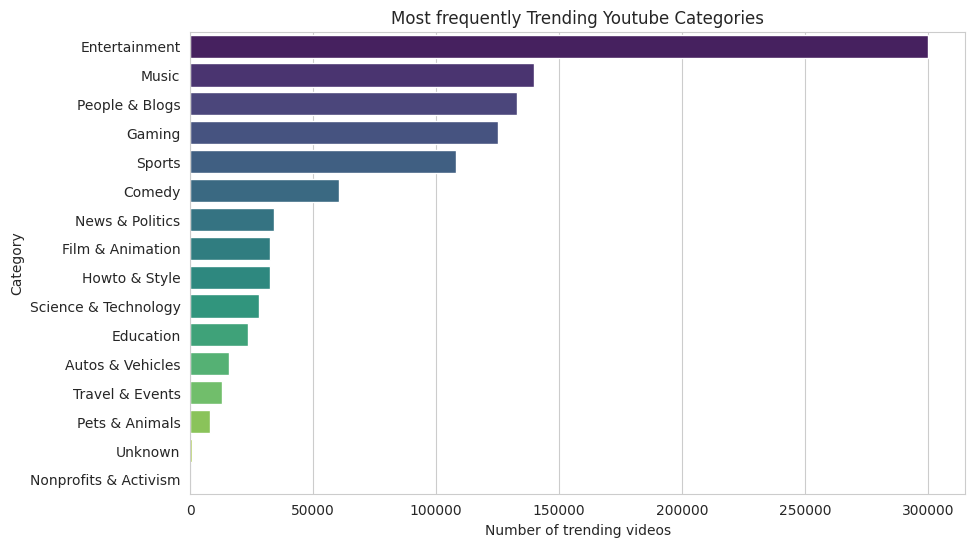

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    palette="viridis"
)

plt.title("Most frequently Trending Youtube Categories")
plt.xlabel("Number of trending videos")
plt.ylabel("Category")

plt.show()

In [44]:
country_category = pd.crosstab(
    youtube["country"],
    youtube["category_name"]
)

print(country_category)

category_name  Autos & Vehicles  Comedy  Education  Entertainment  \
country                                                             
India                      1597   18151       5955          98230   
South Korea                2172   17039       4220          90028   
UK                         6662   12096       6592          57976   
USA                        5488   13181       6654          53920   

category_name  Film & Animation  Gaming  Howto & Style  Music  \
country                                                         
India                      6488   14735           8063  32598   
South Korea                7102   11230          11342  30492   
UK                         7868   45934           5793  33284   
USA                       10920   53224           7098  43388   

category_name  News & Politics  Nonprofits & Activism  People & Blogs  \
country                                                                 
India                     7535                  

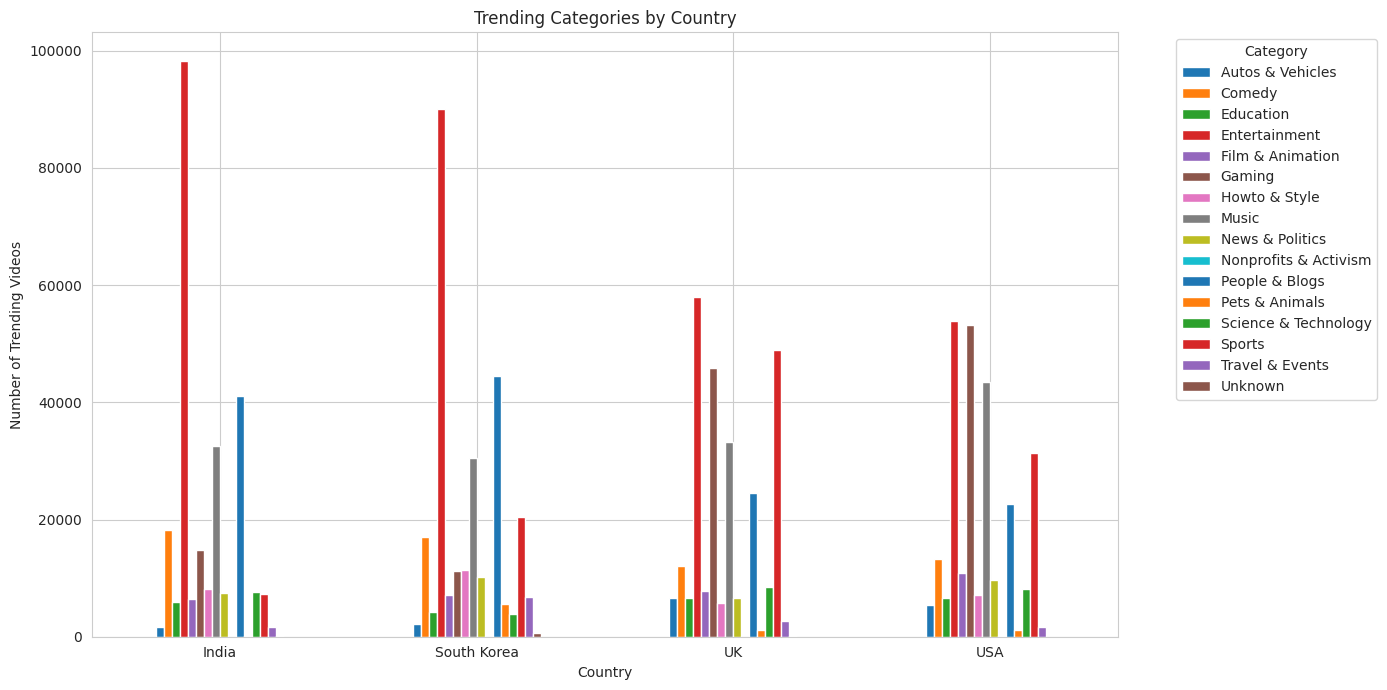

In [45]:
country_category.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Trending Categories by Country")
plt.xlabel("Country")
plt.ylabel("Number of Trending Videos")
plt.xticks(rotation=0)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [48]:
category_views = (
    youtube.groupby("category_name")
    ["view_count"]
    .sum()
    .sort_values(ascending=False)
)

print(category_views)


category_name
Entertainment            812756140866
Music                    682344526848
People & Blogs           219959971726
Gaming                   205991520551
Sports                   155176408020
Comedy                   112873037849
Film & Animation          93871114476
Science & Technology      72481960333
News & Politics           49700798740
Education                 35467582326
Howto & Style             34486565879
Autos & Vehicles          14995067569
Travel & Events           10830639805
Pets & Animals             8228151631
Unknown                     806176281
Nonprofits & Activism       279970874
Name: view_count, dtype: int64


/tmp/ipykernel_1304/2317112669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


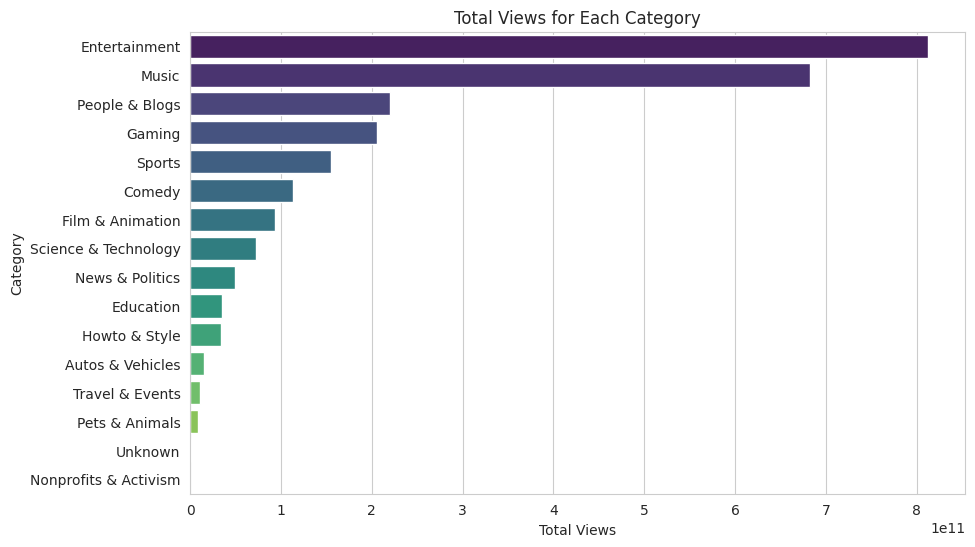

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_views.values,
    y=category_views.index,
    palette="viridis"
)

plt.title("Total Views for Each Category")
plt.xlabel("Total Views")
plt.ylabel("Category")

plt.show()

In [51]:
top_videos = youtube.nlargest(10, "view_count")

top_videos[
    ["title", "country", "category_name", "view_count"]
]

,title,country,category_name,view_count
517464,Discord Loot Boxes are here.,USA,Entertainment,1407643634
517665,Discord Loot Boxes are here.,USA,Entertainment,1406329649
786457,Discord Loot Boxes are here.,UK,Entertainment,1406329649
517264,Discord Loot Boxes are here.,USA,Entertainment,628718636
843993,BTS (ë°©íìë ë¨) 'Butter' Official MV,South Korea,Music,296314174
843793,BTS (ë°©íìë ë¨) 'Butter' Official MV,South Korea,Music,292502967
843584,BTS (ë°©íìë ë¨) 'Butter' Official MV,South Korea,Music,289350312
843374,BTS (ë°©íìë ë¨) 'Butter' Official MV,South Korea,Music,285698612
843139,BTS (ë°©íìë ë¨) 'Butter' Official MV,South Korea,Music,282265069
842933,BTS (ë°©íìë ë¨) 'Butter' Official MV,South Korea,Music,278080610


In [52]:
youtube.nlargest(10, "view_count")

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,country,category_name
517464,cc2-4ci4G84,Discord Loot Boxes are here.,2024-04-01 17:46:17+00:00,UCZ5XnGb-3t7jCkXdawN2tkA,Discord,24,2024-04-03 00:00:00+00:00,[None],1407643634,126926,0,13987,https://i.ytimg.com/vi/cc2-4ci4G84/default.jpg,False,False,Why would we ever bring Loot Boxes into a chat...,USA,Entertainment
517665,cc2-4ci4G84,Discord Loot Boxes are here.,2024-04-01 17:46:17+00:00,UCZ5XnGb-3t7jCkXdawN2tkA,Discord,24,2024-04-04 00:00:00+00:00,[None],1406329649,165173,0,17446,https://i.ytimg.com/vi/cc2-4ci4G84/default.jpg,False,False,Why would we ever bring Loot Boxes into a chat...,USA,Entertainment
786457,cc2-4ci4G84,Discord Loot Boxes are here.,2024-04-01 17:46:17+00:00,UCZ5XnGb-3t7jCkXdawN2tkA,Discord,24,2024-04-04 00:00:00+00:00,[None],1406329649,165173,0,17446,https://i.ytimg.com/vi/cc2-4ci4G84/default.jpg,False,False,Why would we ever bring Loot Boxes into a chat...,UK,Entertainment
517264,cc2-4ci4G84,Discord Loot Boxes are here.,2024-04-01 17:46:17+00:00,UCZ5XnGb-3t7jCkXdawN2tkA,Discord,24,2024-04-02 00:00:00+00:00,[None],628718636,47460,0,4829,https://i.ytimg.com/vi/cc2-4ci4G84/default.jpg,False,False,Why would we ever bring Loot Boxes into a chat...,USA,Entertainment
843993,WMweEpGlu_U,BTS (ë°©íìë ë¨) 'Butter' Official MV,2021-05-21 03:46:13+00:00,UC3IZKseVpdzPSBaWxBxundA,HYBE LABELS,10,2021-06-04 00:00:00+00:00,BIGHIT|ë¹ íí¸|ë°©íìë ë¨|BTS|BANGTAN|ë...,296314174,16464253,181350,6939302,https://i.ytimg.com/vi/WMweEpGlu_U/default.jpg,False,False,BTS (ë°©íìë ë¨) 'Butter' Official MV Cre...,South Korea,Music
843793,WMweEpGlu_U,BTS (ë°©íìë ë¨) 'Butter' Official MV,2021-05-21 03:46:13+00:00,UC3IZKseVpdzPSBaWxBxundA,HYBE LABELS,10,2021-06-03 00:00:00+00:00,BIGHIT|ë¹ íí¸|ë°©íìë ë¨|BTS|BANGTAN|ë...,292502967,16413537,178381,6913277,https://i.ytimg.com/vi/WMweEpGlu_U/default.jpg,False,False,BTS (ë°©íìë ë¨) 'Butter' Official MV Cre...,South Korea,Music
843584,WMweEpGlu_U,BTS (ë°©íìë ë¨) 'Butter' Official MV,2021-05-21 03:46:13+00:00,UC3IZKseVpdzPSBaWxBxundA,HYBE LABELS,10,2021-06-03 00:00:00+00:00,BIGHIT|ë¹ íí¸|ë°©íìë ë¨|BTS|BANGTAN|ë...,289350312,16369715,175204,6889393,https://i.ytimg.com/vi/WMweEpGlu_U/default.jpg,False,False,BTS (ë°©íìë ë¨) 'Butter' Official MV Cre...,South Korea,Music
843374,WMweEpGlu_U,BTS (ë°©íìë ë¨) 'Butter' Official MV,2021-05-21 03:46:13+00:00,UC3IZKseVpdzPSBaWxBxundA,HYBE LABELS,10,2021-06-02 00:00:00+00:00,BIGHIT|ë¹ íí¸|ë°©íìë ë¨|BTS|BANGTAN|ë...,285698612,16319755,172331,6864694,https://i.ytimg.com/vi/WMweEpGlu_U/default.jpg,False,False,BTS (ë°©íìë ë¨) 'Butter' Official MV Cre...,South Korea,Music
843139,WMweEpGlu_U,BTS (ë°©íìë ë¨) 'Butter' Official MV,2021-05-21 03:46:13+00:00,UC3IZKseVpdzPSBaWxBxundA,HYBE LABELS,10,2021-06-02 00:00:00+00:00,BIGHIT|ë¹ íí¸|ë°©íìë ë¨|BTS|BANGTAN|ë...,282265069,16272565,168794,6845770,https://i.ytimg.com/vi/WMweEpGlu_U/default.jpg,False,False,BTS (ë°©íìë ë¨) 'Butter' Official MV Cre...,South Korea,Music
842933,WMweEpGlu_U,BTS (ë°©íìë ë¨) 'Butter' Official MV,2021-05-21 03:46:13+00:00,UC3IZKseVpdzPSBaWxBxundA,HYBE LABELS,10,2021-06-01 00:00:00+00:00,BIGHIT|ë¹ íí¸|ë°©íìë ë¨|BTS|BANGTAN|ë...,278080610,16213755,165082,6817450,https://i.ytimg.com/vi/WMweEpGlu_U/default.jpg,False,False,BTS (ë°©íìë ë¨) 'Butter' Official MV Cre...,South Korea,Music


In [55]:
print("Videos with zero views:",
      (youtube["view_count"] == 0).sum())

Videos with zero views: 203


In [58]:
youtube["engagement_rate"] = (
    (youtube["likes"] + youtube["comment_count"])
    / youtube["view_count"].replace(0, pd.NA)
) * 100

In [59]:
print(youtube["engagement_rate"].describe())

count     1053972.0
unique     929773.0
top             0.0
freq         1101.0
Name: engagement_rate, dtype: float64


In [60]:
print(
    "Missing engagement rates:",
    youtube["engagement_rate"].isna().sum()
)

Missing engagement rates: 203


In [62]:
youtube["engagement_rate"] = pd.to_numeric(
    youtube["engagement_rate"],
    errors="coerce"
)

In [63]:
print(youtube["engagement_rate"].dtype)

float64


In [64]:
top_engagement = youtube.nlargest(
    10, "engagement_rate"
)

top_engagement[
    ["title", "country", "category_name", "engagement_rate"]
]


,title,country,category_name,engagement_rate
2936,Celebrate Onam #WithMe🔥🔥🔥 || നിങ്ങള്‍ക്കുള്ള ഓ...,India,Science & Technology,73.175506
221731,✓ Kallo कल्लो | Ajay Hooda | Princy (Live Show...,India,Music,68.291857
82540,Tanzeel Khan - YEH DIL | DASTAAN,India,Music,67.195127
3157,Celebrate Onam #WithMe🔥🔥🔥 || നിങ്ങള്‍ക്കുള്ള ഓ...,India,Science & Technology,66.930918
3401,Celebrate Onam #WithMe🔥🔥🔥 || നിങ്ങള്‍ക്കുള്ള ഓ...,India,Science & Technology,65.096742
82778,Tanzeel Khan - YEH DIL | DASTAAN,India,Music,62.823289
111007,Kamle | Official Music Video | @akasaofficial ...,India,Music,62.405450
178674,SAHIBA 2.0 || The UK07 Rider X Iqra || Officia...,India,Music,60.859726
168871,SAHIBA - The UK07 Rider X Iqra || Official Mus...,India,Music,58.360946
533497,Stray Kids 『ALL IN』M/V Teaser,UK,Music,57.984741


In [65]:
country_performance = youtube.groupby("country").agg(
    total_views=("view_count", "sum"),
    average_views=("view_count", "mean"),
    average_engagement=("engagement_rate", "mean")
)

country_performance = country_performance.sort_values(
    by="total_views",
    ascending=False
)

print(country_performance)

              total_views  average_views  average_engagement
country                                                     
USA          734860257381   2.734832e+06            5.610372
India        701935690495   2.794308e+06            5.673435
UK           588697064466   2.191177e+06            5.321723
South Korea  484756621432   1.825124e+06            3.210111


/tmp/ipykernel_1304/2288874778.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


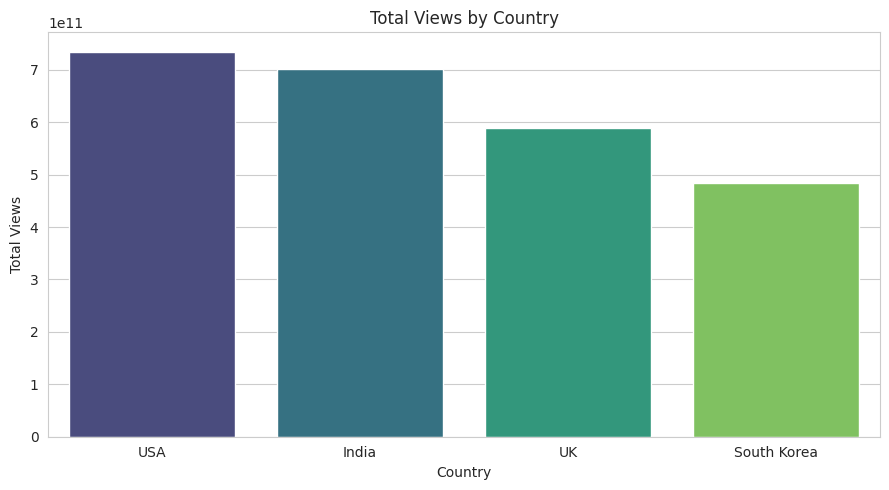

In [66]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=country_performance.index,
    y=country_performance["total_views"],
    palette="viridis"
)

plt.title("Total Views by Country")
plt.xlabel("Country")
plt.ylabel("Total Views")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1304/2157670153.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


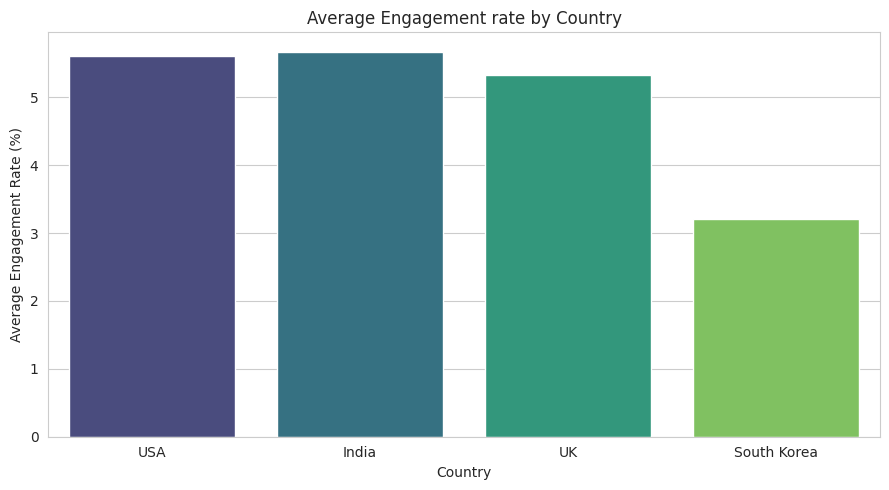

In [67]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=country_performance.index,
    y=country_performance["average_engagement"],
    palette="viridis"
)

plt.title("Average Engagement rate by Country")
plt.xlabel("Country")
plt.ylabel("Average Engagement Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [68]:
numeric_cols = [
    "view_count",
    "likes",
    "dislikes",
    "comment_count",
    "engagement_rate"
]

correlation = youtube[numeric_cols].corr()

print(correlation)

                 view_count     likes  dislikes  comment_count  \
view_count         1.000000  0.805311  0.106735       0.503697   
likes              0.805311  1.000000  0.100818       0.686727   
dislikes           0.106735  0.100818  1.000000       0.145097   
comment_count      0.503697  0.686727  0.145097       1.000000   
engagement_rate    0.011333  0.220053  0.009761       0.113944   

                 engagement_rate  
view_count              0.011333  
likes                   0.220053  
dislikes                0.009761  
comment_count           0.113944  
engagement_rate         1.000000  


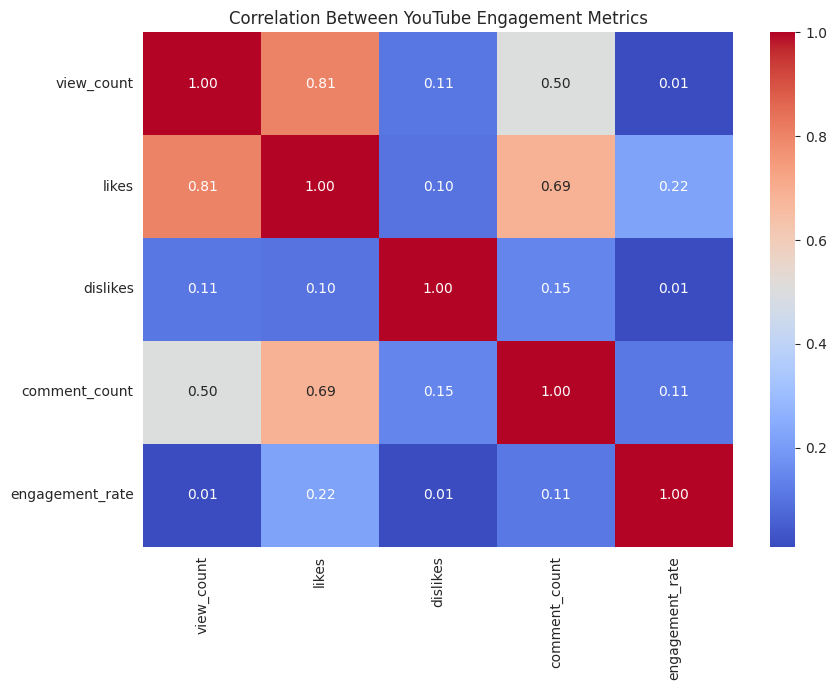

In [69]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between YouTube Engagement Metrics")
plt.tight_layout()
plt.show()

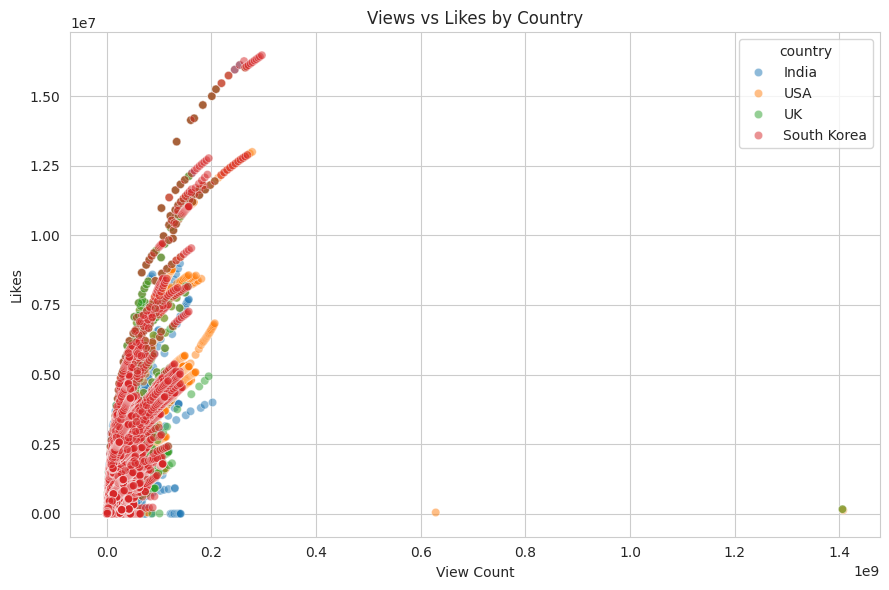

In [70]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=youtube,
    x="view_count",
    y="likes",
    hue="country",
    alpha=0.5
)

plt.title("Views vs Likes by Country")
plt.xlabel("View Count")
plt.ylabel("Likes")
plt.tight_layout()
plt.show()

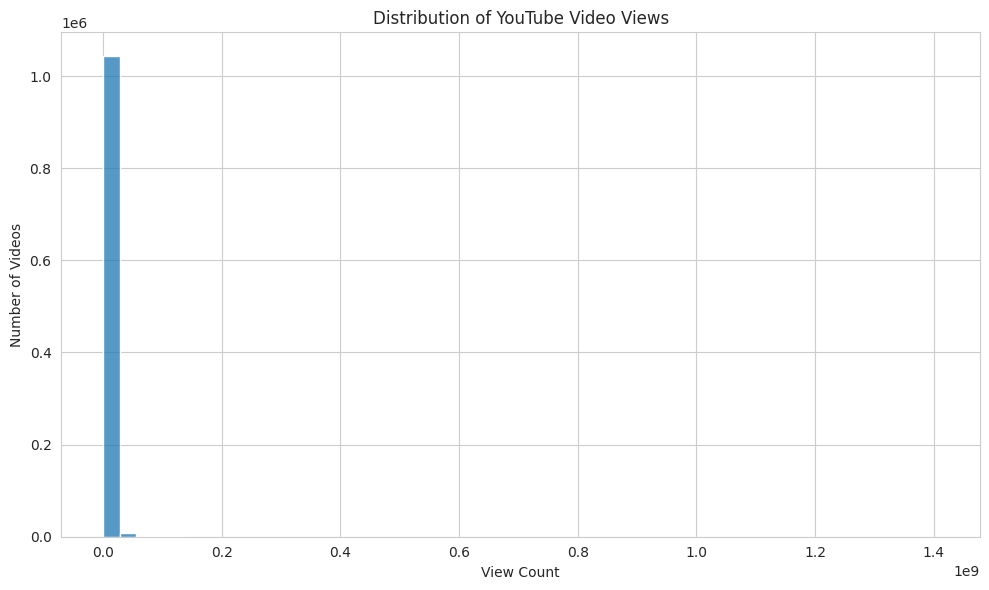

In [71]:
#Distribution of Views
plt.figure(figsize=(10, 6))

sns.histplot(
    data=youtube,
    x="view_count",
    bins=50
)

plt.title("Distribution of YouTube Video Views")
plt.xlabel("View Count")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

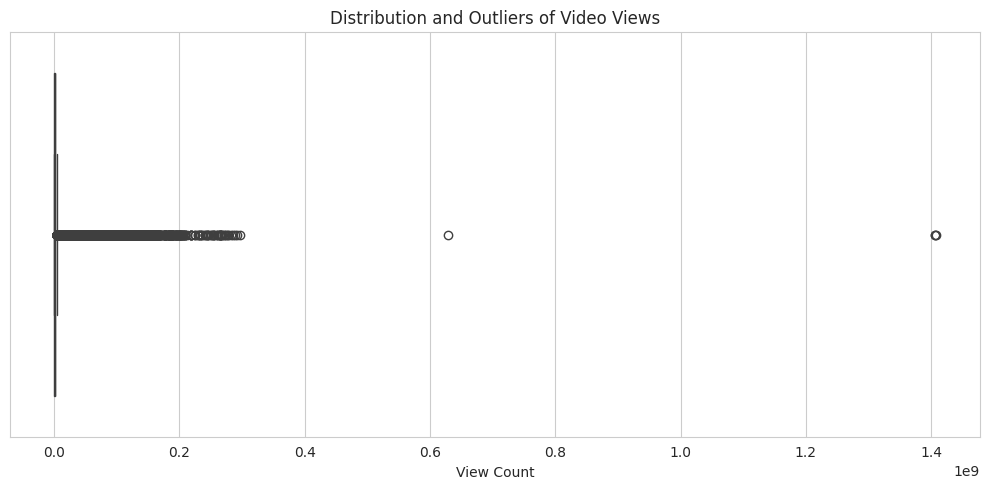

In [72]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=youtube["view_count"]
)

plt.title("Distribution and Outliers of Video Views")
plt.xlabel("View Count")
plt.tight_layout()
plt.show()

In [73]:
!pip install vaderSentiment -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.6 MB/s eta 0:00:00


In [74]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [75]:
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [76]:
youtube["sentiment"] = youtube["title"].apply(get_sentiment)

In [77]:
youtube["sentiment"].value_counts()

,count
sentiment,
Neutral,660999
Positive,234988
Negative,158188


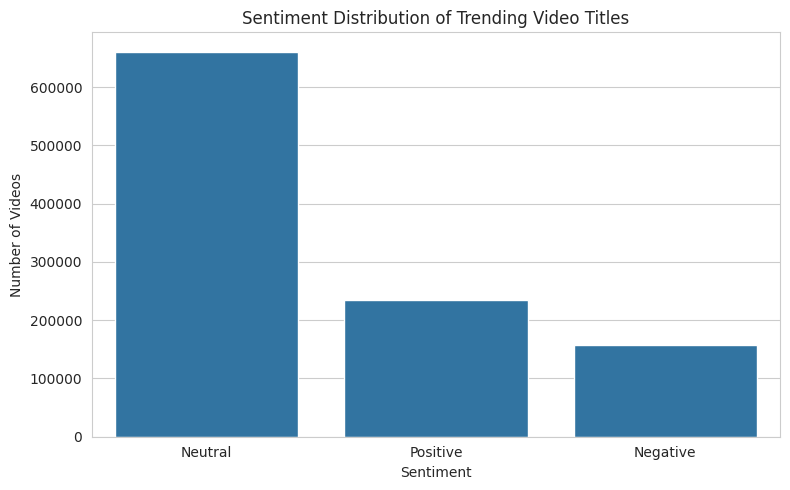

In [78]:
sentiment_counts = youtube["sentiment"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution of Trending Video Titles")
plt.xlabel("Sentiment")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

In [79]:
country_sentiment = pd.crosstab(
    youtube["country"],
    youtube["sentiment"]
)

print(country_sentiment)

sentiment    Negative  Neutral  Positive
country                                 
India           34143   138796     78263
South Korea      7009   238100     20493
UK              58194   138894     71579
USA             58842   145209     64653


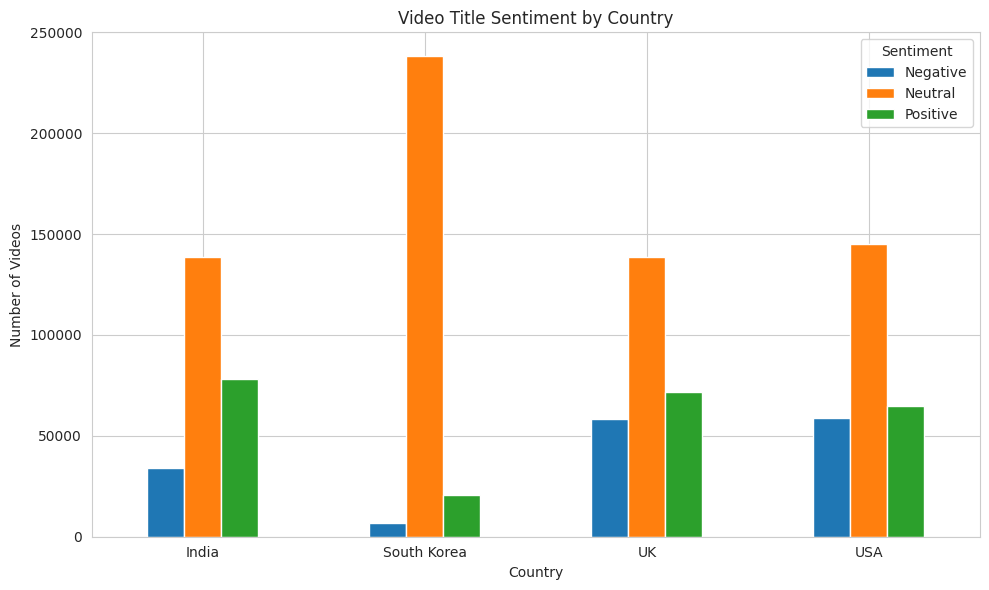

In [80]:
country_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Video Title Sentiment by Country")
plt.xlabel("Country")
plt.ylabel("Number of Videos")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [81]:
sentiment_views = (
    youtube.groupby("sentiment")["view_count"]
    .mean()
    .sort_values(ascending=False)
)

print(sentiment_views)

sentiment
Positive    2.689167e+06
Negative    2.315274e+06
Neutral     2.287566e+06
Name: view_count, dtype: float64


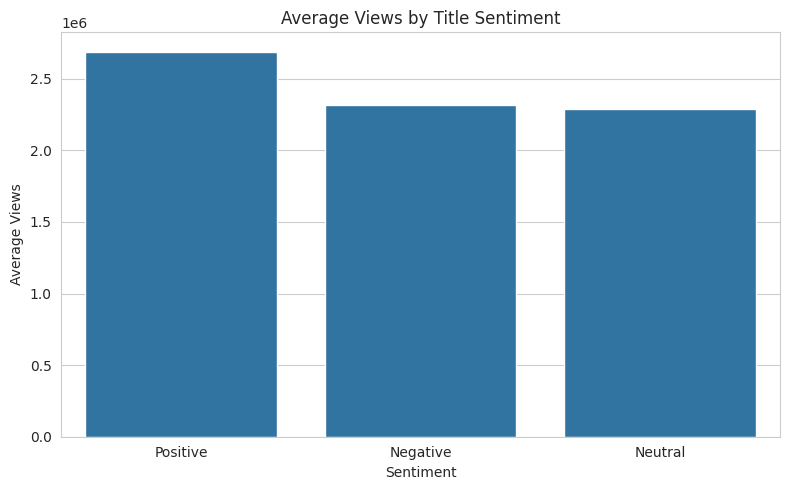

In [82]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_views.index,
    y=sentiment_views.values
)

plt.title("Average Views by Title Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Views")
plt.tight_layout()
plt.show()

In [83]:
trending_duration = youtube.groupby("video_id").agg(
    first_trending_date=("trending_date", "min"),
    last_trending_date=("trending_date", "max"),
    trending_days=("trending_date", "nunique")
)

In [84]:
youtube = youtube.merge(
    trending_duration,
    on="video_id",
    how="left"
)

In [85]:
youtube[
    [
        "video_id",
        "title",
        "country",
        "trending_days"
    ]
].head(10)

,video_id,title,country,trending_days
0,Iot0eF6EoNA,Sadak 2 | Official Trailer | Sanjay | Pooja | ...,India,11
1,x-KbnJ9fvJc,Kya Baat Aa : Karan Aujla (Official Video) Tan...,India,9
2,KX06ksuS6Xo,Diljit Dosanjh: CLASH (Official) Music Video |...,India,8
3,UsMRgnTcchY,Dil Ko Maine Di Kasam Video | Amaal M Ft.Ariji...,India,5
4,WNSEXJJhKTU,"Baarish (Official Video) Payal Dev,Stebin Ben ...",India,7
5,Xma15IYe5tQ,SISTER DOES MY HAIRCUT,India,4
6,uUXE9qUHVzk,Paapi Munda - Mankirt Aulakh Ft. Gur Sidhu | K...,India,7
7,4dRHHupQM-s,Naagin 5 | नागिन 5 | Episode 01 | Recap,India,2
8,-h9fY8j22yg,Ludo | BakLol Video,India,7
9,XM4Kd1gQ7Ek,Jatti Jaandi (Official Video) | Kambi Ft. Mahi...,India,7


In [86]:
longest_trending = (
    youtube[
        [
            "video_id",
            "title",
            "country",
            "category_name",
            "trending_days"
        ]
    ]
    .drop_duplicates("video_id")
    .nlargest(10, "trending_days")
)

longest_trending

,video_id,title,country,category_name,trending_days
219491,3ryID_SwU5E,"$1 Vs $100,000,000 House!",India,Entertainment,37
228111,tnTPaLOaHz8,"$10,000 Every Day You Survive In A Grocery Store",India,Entertainment,37
240230,KOEfDvr4DcQ,"Face Your Biggest Fear To Win $800,000",India,Entertainment,37
244197,tWYsfOSY9vY,I Survived 7 Days In An Abandoned City,India,Entertainment,37
29504,wY6UyatwVTA,"India claim stunning series win, end Australia...",India,Sports,36
61612,hdmx71UjBXs,Turn into orbeez - Tutorial #Shorts,India,Entertainment,36
113448,myjEoDypUD8,Watch the uncensored moment Will Smith smacks ...,India,News & Politics,36
209763,J_z-W4UVHkw,"Every Country On Earth Fights For $250,000!",India,Entertainment,36
228546,QdBZY2fkU-0,Grand Theft Auto VI Trailer 1,India,Gaming,36
230409,9RhWXPcKBI8,"Survive 100 Days Trapped, Win $500,000",India,Entertainment,36


In [87]:
category_duration = (
    youtube.groupby("category_name")["trending_days"]
    .mean()
    .sort_values(ascending=False)
)

print(category_duration)

category_name
Nonprofits & Activism    10.925000
Unknown                   9.398417
Pets & Animals            9.257595
Travel & Events           9.228006
Music                     7.587520
Howto & Style             7.544557
Comedy                    7.481138
People & Blogs            7.196015
Film & Animation          7.178022
Entertainment             7.029405
Sports                    6.647169
News & Politics           6.632655
Gaming                    6.511113
Education                 6.467059
Autos & Vehicles          6.441673
Science & Technology      6.437698
Name: trending_days, dtype: float64


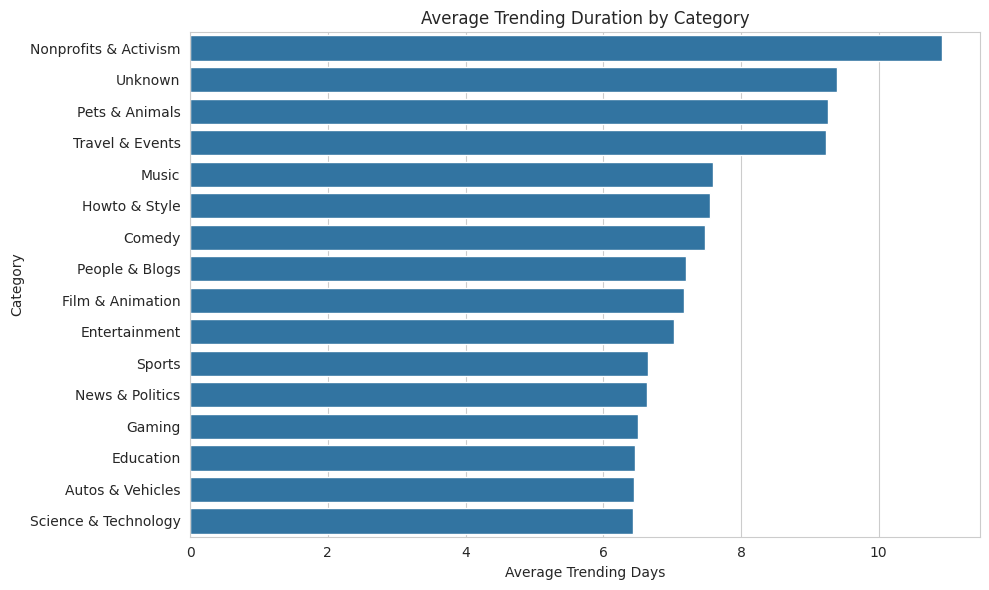

In [88]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_duration.values,
    y=category_duration.index
)

plt.title("Average Trending Duration by Category")
plt.xlabel("Average Trending Days")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [89]:
youtube["trending_month"] = youtube["trending_date"].dt.to_period("M")

/tmp/ipykernel_1304/2289507206.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  youtube["trending_month"] = youtube["trending_date"].dt.to_period("M")


In [90]:
monthly_trending = (
    youtube.groupby("trending_month")
    .size()
)

print(monthly_trending)

trending_month
2020-08    14557
2020-09    22122
2020-10    23704
2020-11    22575
2020-12    22871
2021-01    24292
2021-02    20612
2021-03    25331
2021-04    23412
2021-05    19868
2021-06    35436
2021-07    24747
2021-08    24308
2021-09    23929
2021-10    24732
2021-11    23192
2021-12    23978
2022-01    24682
2022-02    22362
2022-03    24706
2022-04    23922
2022-05    24739
2022-06    23941
2022-07    24733
2022-08    24790
2022-09    23996
2022-10    24377
2022-11    23606
2022-12    24199
2023-01    24347
2023-02    21910
2023-03    24325
2023-04    23336
2023-05    24404
2023-06    23618
2023-07    22916
2023-08    24176
2023-09    22569
2023-10    23963
2023-11    23273
2023-12    23740
2024-01    24062
2024-02    22682
2024-03    23743
2024-04    11392
Freq: M, dtype: int64


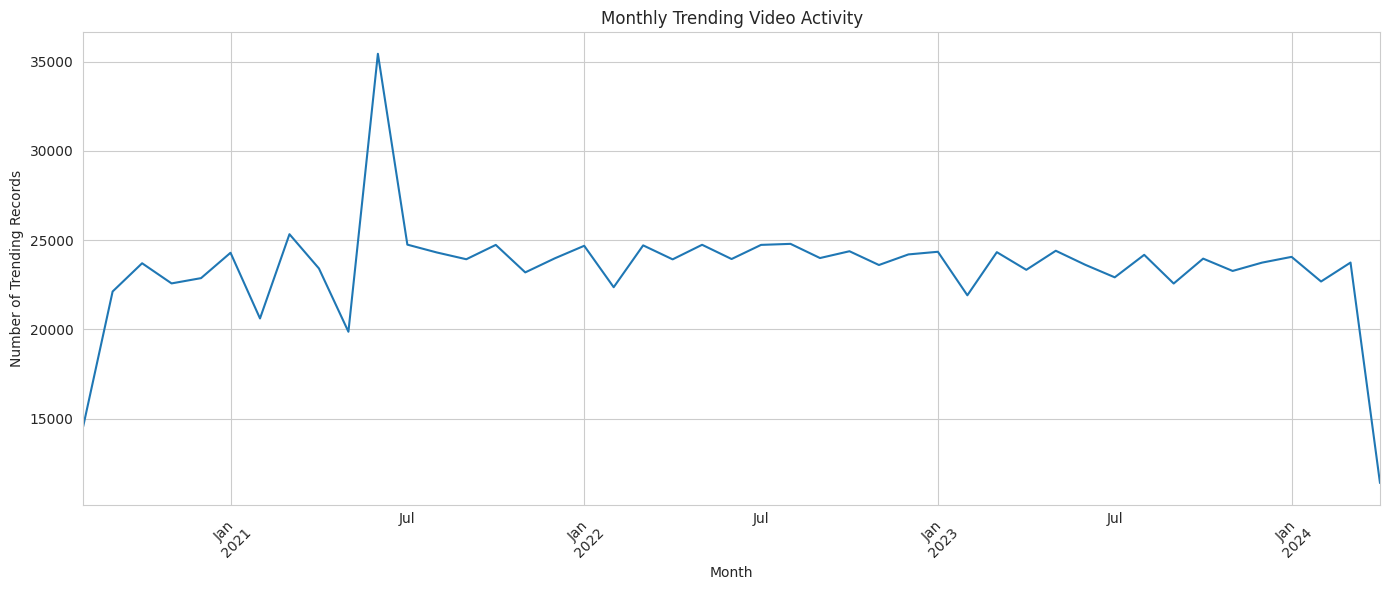

In [91]:
plt.figure(figsize=(14, 6))

monthly_trending.plot()

plt.title("Monthly Trending Video Activity")
plt.xlabel("Month")
plt.ylabel("Number of Trending Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [93]:
monthly_views = (
    youtube.groupby("trending_month")["view_count"]
    .sum()
)

print(monthly_views)

trending_month
2020-08     39167149661
2020-09     45035397366
2020-10     55593045487
2020-11     50605269807
2020-12     48113090870
2021-01     49789984278
2021-02     41556050087
2021-03     55163127944
2021-04     55243536948
2021-05     57939048525
2021-06    103494260314
2021-07     74132971877
2021-08     61163848455
2021-09     58498728575
2021-10     68226665328
2021-11     52679408456
2021-12     61890134479
2022-01     53115919750
2022-02     51700652496
2022-03     62992147769
2022-04     55633448340
2022-05     57176546981
2022-06     54561529661
2022-07     59041565435
2022-08     60886766340
2022-09     64571283404
2022-10     53138394162
2022-11     45590228024
2022-12     49369287267
2023-01     44824403766
2023-02     40873979006
2023-03     46856586834
2023-04     55456901374
2023-05     51618998841
2023-06     50221571101
2023-07     61264099918
2023-08     62147576871
2023-09     56323403069
2023-10     62594424248
2023-11     57713552284
2023-12     69696087777
2

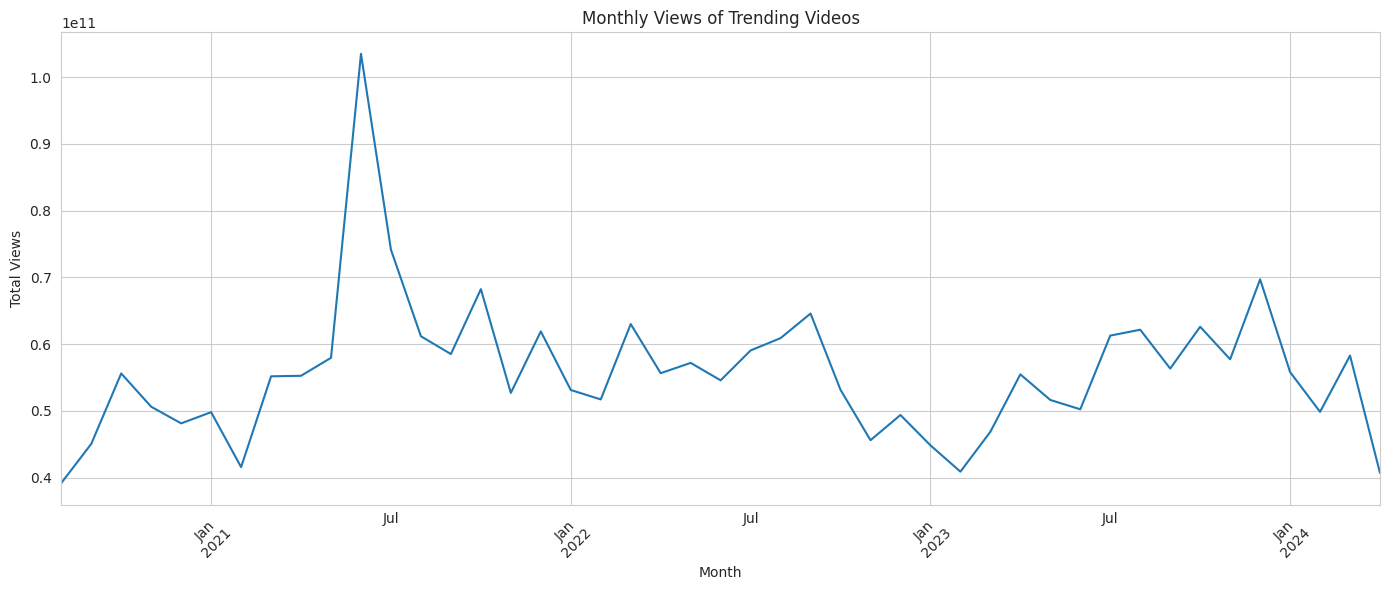

In [94]:
plt.figure(figsize=(14, 6))

monthly_views.plot()

plt.title("Monthly Views of Trending Videos")
plt.xlabel("Month")
plt.ylabel("Total Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
final_columns = [
    "video_id",
    "title",
    "country",
    "category_name",
    "publishedAt",
    "trending_date",
    "view_count",
    "likes",
    "dislikes",
    "comment_count",
    "engagement_rate",
    "sentiment",
    "trending_days",
    "channelTitle"
]

youtube_final = youtube[final_columns].copy()

In [96]:
youtube_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054175 entries, 0 to 1054174
Data columns (total 14 columns):
 #   Column           Non-Null Count    Dtype              
---  ------           --------------    -----              
 0   video_id         1054175 non-null  object             
 1   title            1054175 non-null  object             
 2   country          1054175 non-null  object             
 3   category_name    1054175 non-null  object             
 4   publishedAt      1054175 non-null  datetime64[ns, UTC]
 5   trending_date    1054175 non-null  datetime64[ns, UTC]
 6   view_count       1054175 non-null  int64              
 7   likes            1054175 non-null  int64              
 8   dislikes         1054175 non-null  int64              
 9   comment_count    1054175 non-null  int64              
 10  engagement_rate  1053972 non-null  float64            
 11  sentiment        1054175 non-null  object             
 12  trending_days    1054175 non-null  int64  

In [97]:
youtube_final.head()

,video_id,title,country,category_name,publishedAt,trending_date,view_count,likes,dislikes,comment_count,engagement_rate,sentiment,trending_days,channelTitle
0,Iot0eF6EoNA,Sadak 2 | Official Trailer | Sanjay | Pooja | ...,India,Entertainment,2020-08-12 04:31:41+00:00,2020-08-12 00:00:00+00:00,9885899,224925,3979409,350210,5.817731,Neutral,11,FoxStarHindi
1,x-KbnJ9fvJc,Kya Baat Aa : Karan Aujla (Official Video) Tan...,India,Music,2020-08-11 09:00:11+00:00,2020-08-12 00:00:00+00:00,11308046,655450,33242,405146,9.379127,Neutral,9,Rehaan Records
2,KX06ksuS6Xo,Diljit Dosanjh: CLASH (Official) Music Video |...,India,Music,2020-08-11 07:30:02+00:00,2020-08-12 00:00:00+00:00,9140911,296533,6179,30058,3.572850,Neutral,8,Diljit Dosanjh
3,UsMRgnTcchY,Dil Ko Maine Di Kasam Video | Amaal M Ft.Ariji...,India,Music,2020-08-10 05:30:49+00:00,2020-08-12 00:00:00+00:00,23564512,743931,84162,136942,3.738134,Neutral,5,T-Series
4,WNSEXJJhKTU,"Baarish (Official Video) Payal Dev,Stebin Ben ...",India,Music,2020-08-11 05:30:13+00:00,2020-08-12 00:00:00+00:00,6783649,268817,8798,22984,4.301534,Neutral,7,VYRLOriginals


In [98]:
youtube_final.to_csv(
    "youtube_trending_final.csv",
    index=False
)

In [99]:
summary = (
    youtube_final.groupby(
        ["country", "category_name"]
    ).agg(
        total_views=("view_count", "sum"),
        average_views=("view_count", "mean"),
        average_likes=("likes", "mean"),
        average_comments=("comment_count", "mean"),
        average_engagement=("engagement_rate", "mean"),
        average_trending_days=("trending_days", "mean"),
        video_count=("video_id", "nunique")
    )
    .reset_index()
)

In [100]:
summary.head()

,country,category_name,total_views,average_views,average_likes,average_comments,average_engagement,average_trending_days,video_count
0,India,Autos & Vehicles,1772420930,1.109844e+06,51948.527239,1035.520351,4.031660,3.751409,497
1,India,Comedy,46612078737,2.568017e+06,183311.291885,6432.922318,7.784994,4.665308,4752
2,India,Education,9363034886,1.572298e+06,88545.218304,3332.703946,7.034740,3.574475,2173
3,India,Entertainment,254352055583,2.589352e+06,105385.010160,4114.478968,4.448343,3.914853,33817
4,India,Film & Animation,28697456950,4.423159e+06,119627.696208,6654.334618,4.362582,5.014488,1610


In [101]:
summary.to_csv(
    "youtube_category_summary.csv",
    index=False
)

In [102]:
print(youtube_final.shape)

(1054175, 14)


In [103]:
print(summary.shape)

(60, 9)
